In [1]:
import essentia.standard as es
import numpy as np
import subprocess
import numpy as np
from PIL import Image
import os
import seaborn as sns
import matplotlib.pyplot as plt

[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


In [2]:
import os
import glob
import freesound
import random
import pandas as pd
import json
import itertools
import essentia
import numpy as np

import cProfile
import pstats

import IPython.display as ipd
import essentia.standard as es
import matplotlib.pyplot as plt

from datetime import datetime

In [3]:
from helpers import (
    query_freesound,
    retrieve_sound_preview,
    sounds_to_dataframe,
    delete_dataset_with_gc,
    load_and_detect_onsets,
    plot_waveform_with_onsets,
    inspect_sound_with_repetition,
    evaluate_pipeline,
    run_pipeline_grid_search,
    analyze_repetitiveness,
)

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
from IPython.display import HTML
audio_style = "<style>audio { margin-left: 23px; width: 720px; }</style>"
display(HTML(audio_style))

In [6]:
def load_audio_as_spectrogram_essentia(file_path):
    """
    Loads an audio file and computes its log-magnitude spectrogram using Essentia.
    """
    # 1. Load the audio file 
    # MonoLoader automatically downmixes multi-channel files to mono 
    # and resamples to a uniform 44100Hz by default.
    audio = es.MonoLoader(filename=file_path)()
    
    # 2. Instantiate the required spectral algorithms
    windowing = es.Windowing(type='hann')
    spectrum = es.Spectrum()
    
    # 3. Slice the audio into frames and compute the linear magnitude spectrum
    # frameSize=2048 and hopSize=512 perfectly match standard STFT dimensions
    spec_list = []
    for frame in es.FrameGenerator(audio, frameSize=2048, hopSize=512):
        windowed_frame = windowing(frame)
        frame_spectrum = spectrum(windowed_frame)
        spec_list.append(frame_spectrum)
        
    # 4. Stack frames into a 2D NumPy array (Frequency Bins x Time Frames)
    spectrogram = np.array(spec_list).T
    
    # 5. Convert linear amplitude to Decibel (Log) scale
    # We use np.maximum to clip values at 1e-5 to avoid log(0) baseline crashes
    spectrogram_db = 20 * np.log10(np.maximum(spectrogram, 1e-5))
    
    return spectrogram_db

In [7]:
def compute_ck1_distance(spec_x, spec_y, target_size=(256, 256), quality=5):
    """
    Computes the Campana-Keogh (CK-1) distance between two 2D spectrogram arrays.
    
    Parameters:
    -----------
    spec_x : np.ndarray
        2D array of the first spectrogram.
    spec_y : np.ndarray
        2D array of the second spectrogram.
    target_size : tuple (width, height)
        Dimensions to resize spectrograms. Must be multiples of 16 for MPEG-1 (e.g., 256x256).
    quality : int
        MPEG fixed quality scale (1-31). Lower means higher quality/finer detail resolution.
        Default 5 is a robust sweet spot for texture discovery.
    """
    
    # 1. Helper function to normalize and resize spectrograms to grayscale frames
    def preprocess_spectrogram(spec):
        # Normalize strictly to 0-255 grayscale range
        s_min, s_max = spec.min(), spec.max()
        if s_max > s_min:
            spec_norm = 255.0 * (spec - s_min) / (s_max - s_min)
        else:
            spec_norm = np.zeros_like(spec)
            
        # Resize to standard uniform dimensions using Pillow
        img = Image.fromarray(spec_norm.astype(np.uint8))
        img_resized = img.resize(target_size, Image.Resampling.BILINEAR)
        return np.array(img_resized)

    # Preprocess both inputs
    x = preprocess_spectrogram(spec_x)
    y = preprocess_spectrogram(spec_y)
    width, height = target_size

    # 2. Helper function to pass 2 frames to FFmpeg and get the compressed size in bytes
    def get_mpeg1_compressed_size(frame_1, frame_2):
        f1_bytes = frame_1.tobytes()
        f2_bytes = frame_2.tobytes()
        
        # FFmpeg command optimized for exact conditional algorithmic complexity estimation
        cmd = [
            'ffmpeg', '-y',
            '-f', 'rawvideo',
            '-pix_fmt', 'gray',
            '-s', f'{width}x{height}',
            '-r', '25',                    # Standard framerate input
            '-i', 'pipe:0',                # Read from stdin pipe
            '-vcodec', 'mpeg1video',       # Force legacy MPEG-1 as per the original spec
            '-bf', '0',                    # Disable B-frames (forces frame 2 to be a P-frame)
            '-g', '10',                    # Prevent forcing frame 2 into a new GOP/I-frame
            '-q:v', str(quality),          # CRITICAL: Use constant quality scale instead of fixed bitrate
            '-f', 'mpeg1video',            # Raw video stream container (minimal overhead)
            'pipe:1'                       # Output to stdout pipe
        ]
        
        # Open asynchronous pipe to FFmpeg
        process = subprocess.Popen(
            cmd, stdin=subprocess.PIPE, stdout=subprocess.PIPE, stderr=subprocess.PIPE
        )
        
        # Stream frames into stdin and grab output bitstream from stdout
        stdout, _ = process.communicate(input=f1_bytes + f2_bytes)
        return len(stdout)

    # 3. Compute the four compression elements required by the formula
    c_x_given_y = get_mpeg1_compressed_size(y, x)  # y is I-frame, x is P-frame
    c_y_given_x = get_mpeg1_compressed_size(x, y)  # x is I-frame, y is P-frame
    c_x_given_x = get_mpeg1_compressed_size(x, x)  # Identity baseline x
    c_y_given_y = get_mpeg1_compressed_size(y, y)  # Identity baseline y

    # 4. Final CK-1 Metric calculation
    numerator = c_x_given_y + c_y_given_x
    denominator = c_x_given_x + c_y_given_y
    
    ck1_distance = (numerator / denominator) - 1.0
    return max(0.0, ck1_distance) # Clamp near zero minor float variations

In [8]:
!ls ../data/audio/pickaxe

240801_2698284-hq.ogg  588306_12594692-hq.ogg  674381_13732472-hq.ogg
362711_6460155-hq.ogg  635702_5685306-hq.ogg


In [9]:
spec1 = load_audio_as_spectrogram_essentia("../data/audio/pickaxe/362711_6460155-hq.ogg")

In [10]:
spec2 = load_audio_as_spectrogram_essentia("../data/audio/pickaxe/240801_2698284-hq.ogg")

In [11]:
spec3 = load_audio_as_spectrogram_essentia("../data/audio/rain/116961_2081635-hq.ogg")

In [12]:
distance = compute_ck1_distance(spec2, spec3)

In [13]:
distance

0.5435197817189632

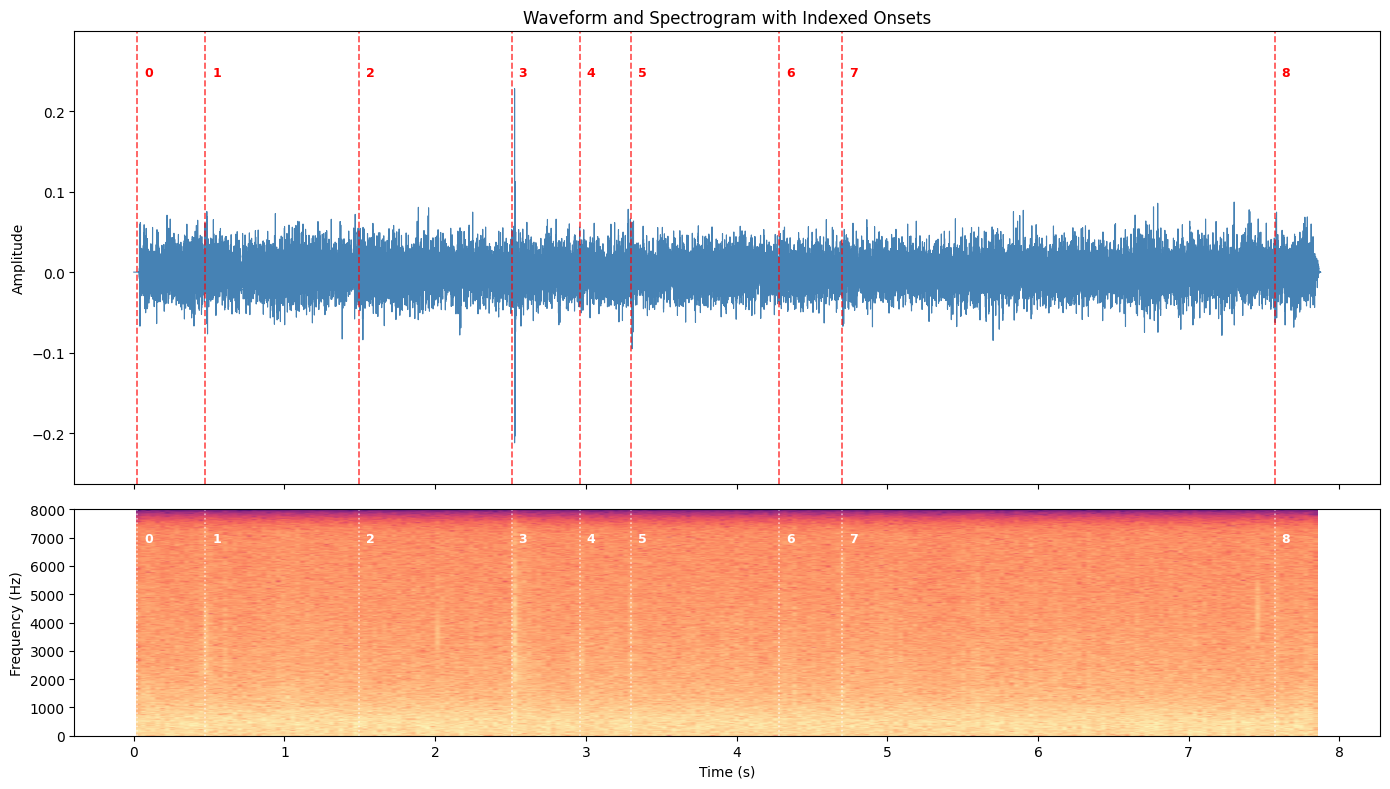

In [14]:
audio, onsets = load_and_detect_onsets("../data/audio/rain/116961_2081635-hq.ogg")
plot_waveform_with_onsets(audio, onsets)
ipd.Audio(audio, rate=16000)

---

In [31]:
def compute_spectrogram_from_chunk(audio_segment):
    """
    Computes a high-density log-magnitude spectrogram optimized for short audio windows.
    """
    # 1. Use smaller frame/hop sizes to maximize native resolution in short windows
    windowing = es.Windowing(type='hann')
    spectrum = es.Spectrum()
    
    spec_list = []
    # FrameSize=512, HopSize=64 gives massive temporal resolution
    for frame in es.FrameGenerator(audio_segment, frameSize=512, hopSize=64):
        windowed_frame = windowing(frame)
        frame_spectrum = spectrum(windowed_frame)
        spec_list.append(frame_spectrum)
        
    if not spec_list:
        return None

    # Transpose to: (Frequency Bins x Time Frames) -> Natively ~257 x 165
    spectrogram = np.array(spec_list).T
    
    # Convert to Decibel scale
    spectrogram_db = 20 * np.log10(np.maximum(spectrogram, 1e-5))
    
    return spectrogram_db

In [33]:
def analyze_recording_onsets_ck(file_path, window_ms=125, target_sr=44100):
    """
    Loads high-res audio, uses the filtered high-res timestamps from the helper,
    extracts a fixed window after each onset, and computes the pairwise CK matrix.
    """
    # 1. Extract the filtered onset timestamps from your existing helper
    # We ignore the low-res audio array it returns for this specific high-res test
    _, onset_times = load_and_detect_onsets(file_path)
    
    # 2. Load the actual high-res audio buffer for high-fidelity spectrograms
    audio_high = es.MonoLoader(filename=file_path, sampleRate=target_sr)()
    
    print(f"Processing: {os.path.basename(file_path)}")
    print(f"Filtered Onsets to process: {len(onset_times)}")
    
    if len(onset_times) < 2:
        print("Not enough onsets to perform pairwise comparison.")
        return None, None
        
    # 3. Extract fixed-size spectrograms for each onset using 44.1kHz math
    window_samples = int((window_ms / 1000.0) * target_sr)
    onset_spectrograms = []
    valid_onset_times = []
    
    for onset in onset_times:
        start_idx = int(onset * target_sr)
        end_idx = start_idx + window_samples
        
        # Now this boundary check matches the audio_high buffer perfectly
        if end_idx > len(audio_high):
            continue
            
        segment = audio_high[start_idx:end_idx]
        spec = compute_spectrogram_from_chunk(segment)
        
        if spec is not None:
            onset_spectrograms.append(spec)
            valid_onset_times.append(onset)
            
    num_onsets = len(onset_spectrograms)
    print(f"Successfully generated {num_onsets} onset spectrograms.")
    
    # 4. Compute the pairwise CK distance matrix
    ck_matrix = np.zeros((num_onsets, num_onsets))
    
    for i in range(num_onsets):
        for j in range(i, num_onsets):

            dist = compute_ck1_distance(onset_spectrograms[i], onset_spectrograms[j])
            ck_matrix[i, j] = dist
            ck_matrix[j, i] = dist  # Symmetric fill
                
    return ck_matrix, valid_onset_times

In [17]:
df = None
print("Found metadata sources:")
for csv_path in glob.glob(os.path.join("../data/meta", "dataset_*.csv")):
    print(csv_path)

    # figure out the used query based on the query metadata file
    json_path = csv_path[:csv_path.rfind(".")] + ".json"
    with open(json_path, "r") as f:
        query_data = json.load(f)
        
    raw_query = query_data.get("query", "")
    
    # 1. Split at the first " -" to drop all exclusions, and strip any trailing whitespace
    clean_query = raw_query.split(" -")[0].strip()
    
    # 2. Swap double quotes for single quotes to prevent ugly CSV triple-quoting
    # '"3 times"' becomes "'3 times'", 'dog barking' remains 'dog barking'
    clean_query = clean_query.replace('"', "'")
    
    if df is None:
        df = pd.read_csv(csv_path)
        df["search_query"] = clean_query
    else:
        local_df = pd.read_csv(csv_path)
        local_df["search_query"] = clean_query
        df = pd.concat([df, local_df], ignore_index=True)

df = df.drop_duplicates(subset=['sound_id'], keep='first').reset_index(drop=True)

Found metadata sources:
../data/meta/dataset_2026-06-15_14-36-36.csv
../data/meta/dataset_2026-05-20_14-27-00.csv
../data/meta/dataset_2026-06-02_15-32-39.csv
../data/meta/dataset_2026-06-02_16-15-49.csv
../data/meta/dataset_2026-06-12_18-50-48.csv
../data/meta/dataset_2026-06-15_15-18-42.csv
../data/meta/dataset_2026-06-02_18-16-48.csv
../data/meta/dataset_2026-06-13_16-52-26.csv
../data/meta/dataset_2026-06-02_16-24-32.csv
../data/meta/dataset_2026-06-14_09-39-52.csv
../data/meta/dataset_2026-06-13_17-47-59.csv
../data/meta/dataset_2026-06-02_17-59-57.csv
../data/meta/dataset_2026-06-02_17-13-17.csv
../data/meta/dataset_2026-05-23_14-14-52.csv
../data/meta/dataset_2026-06-12_18-26-39.csv
../data/meta/dataset_2026-05-23_14-36-27.csv
../data/meta/dataset_2026-06-02_17-08-15.csv
../data/meta/dataset_2026-06-02_16-21-22.csv
../data/meta/dataset_2026-05-23_14-36-09.csv
../data/meta/dataset_2026-06-12_18-54-51.csv
../data/meta/dataset_2026-06-02_15-40-15.csv
../data/meta/dataset_2026-06-12

In [18]:
with open("../data/annotations5.json", "r") as f:
    annotations = json.load(f)

In [19]:
from pprint import pp
pp(annotations)

{'655124': {'repetitive_onset_indices': [0, 1, 2],
            'repetitive_onset_times': [0.5340589284896851,
                                       2.2639455795288086,
                                       3.8196825981140137]},
 '722978': {'repetitive_onset_indices': [0, 1, 2],
            'repetitive_onset_times': [0.18575963377952576,
                                       0.847528338432312,
                                       1.5092970132827759]},
 '765153': {'repetitive_onset_indices': [0, 1, 2],
            'repetitive_onset_times': [0.743038535118103,
                                       3.3785033226013184,
                                       5.398639678955078]},
 '233665': {'repetitive_onset_indices': [0, 1, 2, 3, 4],
            'repetitive_onset_times': [0.02321995422244072,
                                       0.27863946557044983,
                                       0.41795918345451355,
                                       0.5921088457107544,
                

In [73]:
i = list(df["sound_id"]).index(485650)
i

514

Index 514, annotating sound with id: 485650


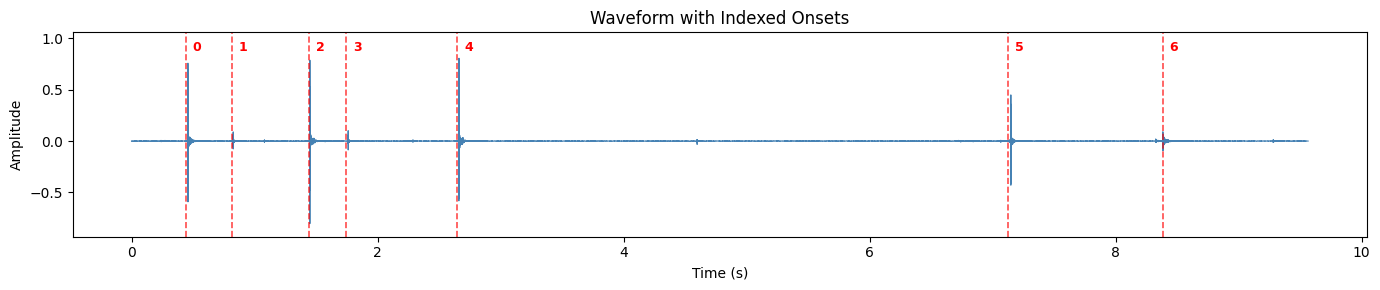

In [74]:
path = df.iloc[i]["local_path"]
sound_id = df.iloc[i]["sound_id"]
print(f"Index {i}, annotating sound with id: {sound_id}")
audio, onsets = load_and_detect_onsets(path)
plot_waveform_with_onsets(audio, onsets, show_spectrogram=False)
ipd.display(ipd.Audio(audio, rate=16000))

Processing: 485650_10331838-hq.ogg
Filtered Onsets to process: 7
Successfully generated 7 onset spectrograms.


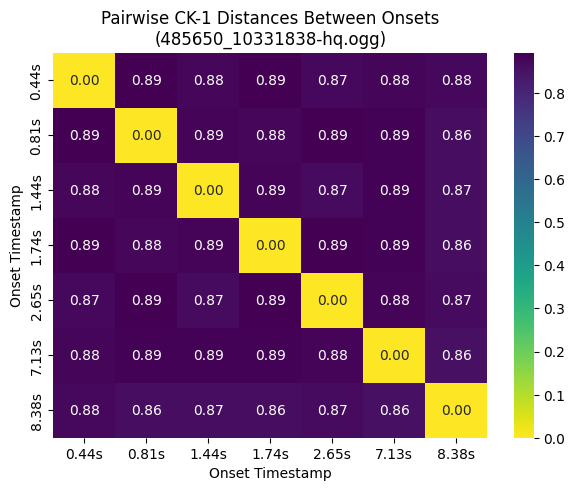

In [75]:
# Pick a row from your dataframe known to contain repeating pickaxe hits
sample_row = df.iloc[i] 
file_path = sample_row['local_path']

# Run the experimental pipeline
matrix, onsets = analyze_recording_onsets_ck(file_path, window_ms=125)

# Plot the matrix as a heatmap
if matrix is not None:
    plt.figure(figsize=(7,5))
    sns.heatmap(
        matrix, 
        cmap="viridis_r", # Reversed viridis: darker colors mean closer to 0 (highly similar)
        xticklabels=[f"{t:.2f}s" for t in onsets],
        yticklabels=[f"{t:.2f}s" for t in onsets],
        annot=True,       # Displays raw CK values in the boxes if onset count is small
        fmt=".2f"
    )
    plt.title(f"Pairwise CK-1 Distances Between Onsets\n({os.path.basename(file_path)})")
    plt.xlabel("Onset Timestamp")
    plt.ylabel("Onset Timestamp")
    plt.show()

In [38]:
matrix

array([[0.        , 0.78694969, 0.80331625, 0.81598785, 0.80851202,
        0.829366  , 0.81153497, 0.817525  , 0.80334701, 0.83971111,
        0.80935205],
       [0.78694969, 0.        , 0.74390175, 0.79804363, 0.73246172,
        0.803747  , 0.73481634, 0.79967365, 0.73821544, 0.8169616 ,
        0.7421014 ],
       [0.80331625, 0.74390175, 0.        , 0.81135855, 0.7397699 ,
        0.81135499, 0.74671031, 0.79769258, 0.74694441, 0.80135056,
        0.74498643],
       [0.81598785, 0.79804363, 0.81135855, 0.        , 0.83533426,
        0.60370181, 0.84148579, 0.6271905 , 0.82420932, 0.64124616,
        0.84242502],
       [0.80851202, 0.73246172, 0.7397699 , 0.83533426, 0.        ,
        0.84997176, 0.76258229, 0.83320844, 0.78031272, 0.83528523,
        0.78375475],
       [0.829366  , 0.803747  , 0.81135499, 0.60370181, 0.84997176,
        0.        , 0.85339952, 0.5853042 , 0.83748502, 0.59822288,
        0.85452121],
       [0.81153497, 0.73481634, 0.74671031, 0.84148579, 0.

In [41]:
def evaluate_matrix_contrast(matrix, group_indices):
    """
    Computes standard intra-cluster, inter-cluster, and out-group metrics.
    
    Parameters:
    - matrix: 2D symmetric NumPy array of pairwise distances
    - group_indices: list or array of target indices (e.g., [3, 5, 7, 9])
    """
    num_elements = matrix.shape[0]
    all_indices = np.arange(num_elements)
    
    # 1. Separate the indices into Group (G) and Non-Group (N)
    g_idx = np.array(group_indices)
    n_idx = np.array([i for i in all_indices if i not in g_idx])
    
    # 2. Average In-Group Distance (Excluding Diagonal Zeros)
    if len(g_idx) > 1:
        in_group_submatrix = matrix[g_idx[:, None], g_idx]
        # Mask out the diagonal elements
        diag_mask = ~np.eye(in_group_submatrix.shape[0], dtype=bool)
        avg_in_group = np.mean(in_group_submatrix[diag_mask])
    else:
        avg_in_group = 0.0  # Not enough elements to have a pair
        
    # 3. Average Out-Group Distance (Excluding Diagonal Zeros)
    if len(n_idx) > 1:
        out_group_submatrix = matrix[n_idx[:, None], n_idx]
        diag_mask_n = ~np.eye(out_group_submatrix.shape[0], dtype=bool)
        avg_out_group = np.mean(out_group_submatrix[diag_mask_n])
    else:
        avg_out_group = 0.0
        
    # 4. Average Between Group and Non-Group Distance
    if len(g_idx) > 0 and len(n_idx) > 0:
        between_submatrix = matrix[g_idx[:, None], n_idx]
        avg_between = np.mean(between_submatrix)
    else:
        avg_between = 0.0
        
    # 5. Compute Contrast Ratio
    contrast_ratio = avg_between / avg_in_group if avg_in_group > 0 else 0.0
    
    return {
        "Avg In-Group (Intra)": avg_in_group,
        "Avg Out-Group": avg_out_group,
        "Avg Between (Inter)": avg_between,
        "Contrast Ratio": contrast_ratio
    }

In [63]:
evaluate_matrix_contrast(matrix, [1, 4, 5])

{'Avg In-Group (Intra)': np.float64(0.8334000967827642),
 'Avg Out-Group': np.float64(0.6488850390878739),
 'Avg Between (Inter)': np.float64(0.8146704577424049),
 'Contrast Ratio': np.float64(0.9775262336629637)}